# **1. Introduction: The Case for Cross-Learning**
- __Act 2:__ The Strategic Approach (Global Scaling). 
- **Goal:** Demonstrate how to engineer a pipeline that handles massive data (30k series) on a single machine, and reveal the "RMSE Paradox."
- Explain the concept: Learning shared patterns (e.g., "Christmas effect") across all 30,000 items simultaneously.


# **2. RAM-Optimized Data Pipeline**
- Import the custom loader: `from src.data_loader import load_global_m5`.
- Show the downcasting (`float32`, `int16`) and the logic of cutting history before Day 1100 to save memory.

In [5]:
import pandas as pd
import numpy as np
import gc
import os
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MQLoss
# from sklearn.preprocessing import OrdinalEncoder

In [3]:
# def reduce_mem_usage(df, verbose=True):
def read_and_squeeze(file_name, INPUT_DIR_PATH = '../data/', verbose=True):
    
    # check if the file_name is a string
    if not isinstance(file_name, str):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. {file_name} must be a string.')
    # check if the file exists at the specified path
    if not os.path.exists(INPUT_DIR_PATH+file_name):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. "{file_name}" cannot be retrieved from "{INPUT_DIR_PATH}". Check if "INPUT_DIR_PATH" is correct.')

    df = pd.read_csv(INPUT_DIR_PATH+file_name)
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics: 
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'For {file_name}, mem. usage decreased from {start_mem:5.2f} Mb to {end_mem:5.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

In [97]:
# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
HORIZON = 28
# We only load data after day 1000 (approx last 2 years). 
# Training on 5 years of history on a laptop is overkill/impossible.
START_DAY = 1200 

print(f"Loading Full M5 Dataset (Optimized for Laptop RAM)...")

# ==========================================
# 2. DATA LOADING (CHUNKED & TYPED)
# ==========================================
# We load strictly necessary columns to keep memory footprint low

# A. CALENDAR
df_cal = read_and_squeeze('calendar.csv')
# Pre-process calendar to minimize merge footprint later
df_cal['date'] = pd.to_datetime(df_cal['date'])
df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))
# Filter calendar to relevant window
df_cal = df_cal[df_cal['d_int'] >= START_DAY]
# Select only needed cols
df_cal = df_cal[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast SNAP to int8
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# B. SALES (The Big One)
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')
# Melt immediately
print("Melting (This spikes RAM)...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='y')
del df_sales; gc.collect()

# Convert d to int for filtering
df['d_int'] = df['d'].apply(lambda x: int(x.split('_')[1]))

# Filter History EARLY (Save RAM before merging)
print(f"Filtering history < Day {START_DAY}...")
df = df[df['d_int'] >= START_DAY]

# C. MERGE CALENDAR
print("Merging Calendar...")
df = df.merge(df_cal, on='d', how='left')
# Drop 'd' (string) to save memory, we have 'd_int' and 'date'
df = df.drop(columns=['d'])

# D. PRICES
print("Loading & Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')
df = df.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

Loading Full M5 Dataset (Optimized for Laptop RAM)...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting (This spikes RAM)...
Filtering history < Day 1200...
Merging Calendar...
Loading & Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)


0

In [98]:
# ==========================================
# 3. FEATURE ENGINEERING (IN-PLACE)
# ==========================================
print("Engineering Features...")

# Rename for NF
df = df.rename(columns={'id': 'unique_id', 'date': 'ds'})

# Sort (Critical)
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# 1. Price Filling & Masking
print("  - Processing Prices...")
df['is_available'] = (~df['sell_price'].isna()).astype('int8')
df['sell_price'] = df['sell_price'].astype('float32') # Use float32
df['sell_price'] = df.groupby('unique_id')['sell_price'].transform(lambda x: x.ffill().bfill())

# 2. Events
print("  - Processing Events...")
df['event_name_1'] = df['event_name_1'].fillna('None')
df['is_event'] = (df['event_name_1'] != 'None').astype('int8')

# 3. SNAP Logic (Dynamic)
# Since we have data from CA, TX, WI, we need a single 'snap_active' column
# that matches the state of the item.
print("  - Processing SNAP columns...")
conditions = [
    df['state_id'] == 'CA',
    df['state_id'] == 'TX',
    df['state_id'] == 'WI'
]
choices = [df['snap_CA'], df['snap_TX'], df['snap_WI']]
df['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# DROP UNUSED COLUMNS TO SAVE RAM FOR GPU
cols_to_drop = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
                'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']
df = df.drop(columns=cols_to_drop)

# Final selection
Y_df = df[['unique_id', 'ds', 'y', 'sell_price', 'is_available', 'snap_active', 'is_event','d_int']]

print(f"Final Dataset Shape: {Y_df.shape}")
print(f"Memory Usage: {Y_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

del df, df_cal
gc.collect()

# ==========================================
# 4. SPLIT
# ==========================================
max_d = Y_df['d_int'].max()
split_date = Y_df[Y_df['d_int'] == (max_d - HORIZON)]['ds'].min()

train_df = Y_df[Y_df['ds'] <= split_date]
test_df = Y_df[Y_df['ds'] > split_date]

futr_exog_df = test_df[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_active', 'is_event']]

Engineering Features...
  - Processing Prices...
  - Processing Events...
  - Processing SNAP columns...
Final Dataset Shape: (22623580, 8)
Memory Usage: 2.51 GB


In [99]:
display(train_df)
display(test_df)

,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
0,FOODS_1_001_CA_1_evaluation,2014-05-12,1,2.240234,1,0,0,1200
1,FOODS_1_001_CA_1_evaluation,2014-05-13,2,2.240234,1,0,0,1201
2,FOODS_1_001_CA_1_evaluation,2014-05-14,0,2.240234,1,0,0,1202
3,FOODS_1_001_CA_1_evaluation,2014-05-15,0,2.240234,1,0,0,1203
4,FOODS_1_001_CA_1_evaluation,2014-05-16,0,2.240234,1,0,0,1204
...,...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912


,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
714,FOODS_1_001_CA_1_evaluation,2016-04-25,2,2.240234,1,0,0,1914
715,FOODS_1_001_CA_1_evaluation,2016-04-26,0,2.240234,1,0,0,1915
716,FOODS_1_001_CA_1_evaluation,2016-04-27,0,2.240234,1,0,0,1916
717,FOODS_1_001_CA_1_evaluation,2016-04-28,0,2.240234,1,0,0,1917
718,FOODS_1_001_CA_1_evaluation,2016-04-29,0,2.240234,1,0,0,1918
...,...,...,...,...,...,...,...,...
22623575,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,0,5.941406,1,0,0,1937
22623576,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,0,5.941406,1,0,0,1938
22623577,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,0,5.941406,1,0,0,1939
22623578,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,0,5.941406,1,0,0,1940


Use MQLoss to see if this works well

In [108]:
import shutil

from pytorch_lightning.loggers import CSVLogger
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts


# ==========================================
# 5 MODEL DEFINITION (FULL DATASET MODE)
# ==========================================
print("Setting up Global N-BEATSx...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
if os.path.exists("logs/nbeats_mqloss_stable_full"):
    shutil.rmtree("logs/nbeats_mqloss_stable_full")



logger_MQLoss_stable_full = CSVLogger("logs", name="nbeats_mqloss_stable_full")

common_params = dict(
    h=HORIZON,
    input_size=370, 
    scaler_type='robust',
    max_steps=8000,          # Give it more time
    val_check_steps=100,     # Check less frequently to speed up
    early_stop_patience_steps=15,
    dropout_prob_theta=0.2,  # Slight increase to force robust features
    futr_exog_list=['sell_price', 'is_available', 'snap_active', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    batch_size=512,         # <--- Increased for gradient stability
    enable_progress_bar=True
)

model_mqloss_stable_full = NBEATSx(
    **common_params,
    learning_rate=5e-4,      # <--- Lowered from 1e-3 (Slower but safer)
    loss=MQLoss(quantiles=[0.5, 0.8, 0.9]), # <--- Back to the correct loss for retail
    logger=logger_MQLoss_stable_full,
    
    lr_scheduler=CosineAnnealingWarmRestarts,
    lr_scheduler_kwargs={
        'T_0': 2000,         # <--- Restart later (let it settle)
        'T_mult': 4,         # <--- Double the cycle length each time
        'eta_min': 1e-6
    },
    alias='NBEATSx_MQLoss_Stable'
)

nf_mqloss_stable_full = NeuralForecast(
    models=[model_mqloss_stable_full],
    freq='D'
)

Seed set to 1


Setting up Global N-BEATSx...


In [109]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
print("Starting Global Training...")

# val_size=28 triggers the internal validation loop using the last 28 days of train_df
nf_mqloss_stable_full.fit(df=train_df, val_size=28)

print("Global Training Complete.")

Starting Global Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.8 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.7 K    Non-trainable params
5.8 M     Total params
23.007    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=8000` reached.


Global Training Complete.


In [110]:
# ==========================================
# 7. SAVE MODEL
# ==========================================
print("Saving Model to Disk...")

# This creates a folder named 'nbeatsx_m5_global'
# overwrite=True allows you to re-run this cell without errors
nf_mqloss_stable_full.save(path='./nf_mqloss_stable_full_7', overwrite=True, save_dataset=True)

print("Model saved successfully to './nf_mqloss_stable_full_7'")

Saving Model to Disk...
Model saved successfully to './nf_mqloss_stable_full_7'


In [111]:
print("Predicting...")
forecasts_nf_mqloss_stable_full = nf_mqloss_stable_full.predict(futr_df=futr_exog_df)
results_mqloss_stable_full = forecasts_nf_mqloss_stable_full.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

display(results_mqloss_stable_full)

Predicting...


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0


In [112]:
print("Calculating RMSE...")
rmse_mqloss_stable_full = np.sqrt(np.mean((results_mqloss_stable_full['y'] - results_mqloss_stable_full['NBEATSx_MQLoss_Stable-median']) ** 2))

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_mqloss_stable_full:.4f}")
print("="*40)

Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.1814


In [11]:
print("Calculating RMSE...")
rmse_mqloss_stable_full = np.sqrt(np.mean((results_mqloss_stable_full['y'] - results_mqloss_stable_full['NBEATSx_MQLoss_Stable-median']) ** 2))

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_mqloss_stable_full:.4f}")
print("="*40)

Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.2017


Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.1975


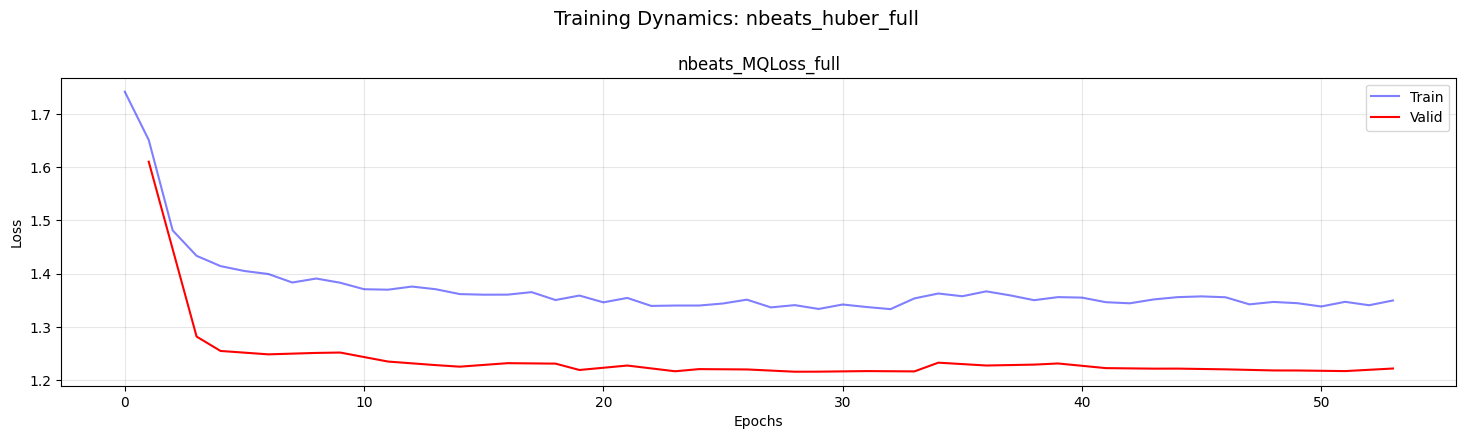

In [40]:
import matplotlib.pyplot as plt

m_df = pd.read_csv("logs/nbeats_mqloss_stable_full/version_0/metrics.csv")
train_m_df = m_df[['epoch', 'train_loss_epoch']].dropna()
valid_m_df = m_df[['epoch', 'valid_loss']].dropna()

plt.figure(figsize=(18, 4))
plt.plot(train_m_df['epoch'], train_m_df['train_loss_epoch'], label='Train', color='blue', alpha=0.5)
plt.plot(valid_m_df['epoch'], valid_m_df['valid_loss'], label='Valid', color='red', linewidth=1.5)

plt.title(f"nbeats_MQLoss_full")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle(f"Training Dynamics: nbeats_huber_full", fontsize=14, y=1.05)
plt.show()

# **3. Model A: Global N-BEATSx (The Challenger)**
- Setup the Global Model (Batch Size 1024).
- Train on full dataset.
- **Result:** Print Global RMSE (~2.36).

# **4. Model B: Global LightGBM (The Control)**
- *Critical Step:* We must train LightGBM on the *same* global data to compare fairly.
- Setup Global LightGBM (feature engineering on 30k items).
- Train (this will take the ~15 mins).
- **Result:** Print Global RMSE (~2.19).

### Loading and preprocessing data

In [6]:
import pandas as pd
import numpy as np
import torch
import lightgbm as lgb
import gc

# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
TARGET = 'sales'
HORIZON = 28
# We need a buffer to calculate lags. 
# If we want to train from Day 1200, we need Day 1140 loaded to calc lag_60.
START_DAY = 1200 
BUFFER = 60 

print(f"Loading Global M5 Dataset for LightGBM...")

# ==========================================
# 2. DATA LOADING (The RAM Safe Way)
# ==========================================

# A. SALES
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')

# Melt
print("Melting...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_lgbm_glob = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='sales')
del df_sales; gc.collect()

# Convert d to int
df_lgbm_glob['d_int'] = df_lgbm_glob['d'].apply(lambda x: int(x.split('_')[1]))
# FILTER EARLY: Keep only needed history + buffer
print(f"Filtering history < Day {START_DAY - BUFFER}...")
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= (START_DAY - BUFFER)]

# Downcast Sales immediately
df_lgbm_glob['sales'] = df_lgbm_glob['sales'].astype('float32')

# B. CALENDAR
print("Merging Calendar...")
df_cal = read_and_squeeze('calendar.csv')

df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))
# Filter Calendar
df_cal = df_cal[df_cal['d_int'] >= (START_DAY - BUFFER)]
# Select only needed
df_cal = df_cal[['d', 'date', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'wm_yr_wk', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast Snaps
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# Merge
df_lgbm_glob = df_lgbm_glob.merge(df_cal, on='d', how='left')
# df_lgbm_glob = df_lgbm_glob.drop(columns=['d']) # Drop string column
del df_cal; gc.collect()

# C. PRICES
print("Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')

df_lgbm_glob = df_lgbm_glob.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

# Fill Prices
df_lgbm_glob['sell_price'] = df_lgbm_glob['sell_price'].astype('float32')
# We do a simplified fill for memory speed (forward fill per group is slow in pandas on 50M rows)
# We will trust LightGBM to handle NaNs, or do a simple fill.
# Let's do a simple global fill to prevent errors, as precise GroupBy fill is RAM heavy.
# Note: For a "Senior" Baseline, accurate filling is better, but RAM is the constraint.
# Let's try the transform. If it crashes, remove this line.
print("Filling Prices (This might be slow)...")
df_lgbm_glob['sell_price'] = df_lgbm_glob.groupby('id')['sell_price'].transform(lambda x: x.ffill().bfill())

Loading Global M5 Dataset for LightGBM...
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting...
Filtering history < Day 1140...
Merging Calendar...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Filling Prices (This might be slow)...


In [126]:
df_lgbm_glob.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,d_int,date,event_name_1,wm_yr_wk,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,NaN,11406,0,1,0,8.257812
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,NaN,11406,0,1,0,3.970703
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,NaN,11406,0,1,0,2.970703
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,1.0,1140,2014-03-13,NaN,11406,0,1,0,4.640625
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,NaN,11406,0,1,0,3.080078


In [7]:
df_calndr = read_and_squeeze('calendar.csv')
display(df_calndr)

For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


### Feature engeneering

In [42]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("Engineering Features...")

# 1. Encode Categoricals (LightGBM likes Integers)
# We use Label Encoding.
cat_feats = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in cat_feats:
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('category')

# 2. Dynamic SNAP (Same logic as N-BEATSx for fairness)
conditions = [
    df_lgbm_glob['state_id'] == 'CA',
    df_lgbm_glob['state_id'] == 'TX',
    df_lgbm_glob['state_id'] == 'WI'
]
choices = [df_lgbm_glob['snap_CA'], df_lgbm_glob['snap_TX'], df_lgbm_glob['snap_WI']]
df_lgbm_glob['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# 3. Lags & Rolling
# We calculate these only where d_int >= START_DAY to save compute, 
# but pandas shift operates on the whole index.
print("Creating Lags...")
lags = [28, 35, 42, 49]
for lag in lags:
    df_lgbm_glob[f'lag_{lag}'] = df_lgbm_glob.groupby('id')['sales'].shift(lag).astype('float32')

print("Creating Rolling Means...")
df_lgbm_glob['rolling_mean_7'] = df_lgbm_glob.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(7).mean()).astype('float32')
df_lgbm_glob['rolling_mean_28'] = df_lgbm_glob.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(28).mean()).astype('float32')

# ==========================================
# 4. TRAINING PREP
# ==========================================
# Now we cut off the buffer. We only wanted it to calculate the lags.
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= START_DAY]

# Drop NaNs created by lags
df_lgbm_glob = df_lgbm_glob.dropna(subset=['rolling_mean_28', 'lag_28'])

# Split
max_d = df_lgbm_glob['d_int'].max()
test_start_d = max_d - HORIZON
valid_start_d = test_start_d - HORIZON

train_mask = df_lgbm_glob['d_int'] < valid_start_d
valid_mask = (df_lgbm_glob['d_int'] >= valid_start_d) & (df_lgbm_glob['d_int'] < test_start_d)
test_mask = df_lgbm_glob['d_int'] >= test_start_d
test_mask_0 = (df_lgbm_glob['d_int'] >= test_start_d) & (df_lgbm_glob['d_int'] < max_d)

# Define features (Drop IDs that aren't features)
drop_cols = ['sales', 'd_int', 'id', 'd', 'date', 'wm_yr_wk', 'snap_CA', 'snap_TX', 'snap_WI']
features = [c for c in df_lgbm_glob.columns if c not in drop_cols]

print(f"Training on {train_mask.sum()} rows. Validating on {valid_mask.sum()} rows.")
print(f"Testing on {test_mask.sum()} rows. Testing_0 on {test_mask_0.sum()} rows.")
print(f"Features: {features}")

# Create LGB Datasets
# free_raw_data=True helps free up pandas memory after loading into LGB
train_data = lgb.Dataset(
    df_lgbm_glob[train_mask][features], 
    label=df_lgbm_glob[train_mask]['sales'], 
    categorical_feature=cat_feats,
    free_raw_data=True
)
valid_data = lgb.Dataset(
    df_lgbm_glob[valid_mask][features], 
    label=df_lgbm_glob[valid_mask]['sales'], 
    reference=train_data,
    free_raw_data=True
)

# Clean up Pandas to free RAM for LightGBM Training
# del df; gc.collect()

Engineering Features...
Creating Lags...
Creating Rolling Means...
Training on 20885650 rows. Validating on 853720 rows.
Testing on 884210 rows. Testing_0 on 853720 rows.
Features: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'sell_price', 'snap_active', 'lag_28', 'lag_35', 'lag_42', 'lag_49', 'rolling_mean_7', 'rolling_mean_28']


### Training

In [43]:
# ==========================================
# 5. TRAINING
# ==========================================
print("Training Global LightGBM...")

params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.1,
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 128,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'n_jobs': -1,
    'seed': 42,
    'verbose': -1,
    'bin_construct_sample_cnt': 200000 # Speed up binning for large data
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1500, # Increased rounds for full dataset
    valid_sets=[train_data, valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(50)]
)



Training Global LightGBM...
Training until validation scores don't improve for 200 rounds
[50]	training's rmse: 2.31652	valid_1's rmse: 2.24326
[100]	training's rmse: 2.262	valid_1's rmse: 2.20282
[150]	training's rmse: 2.24087	valid_1's rmse: 2.19793
[200]	training's rmse: 2.22229	valid_1's rmse: 2.19708
[250]	training's rmse: 2.20948	valid_1's rmse: 2.19437
[300]	training's rmse: 2.19942	valid_1's rmse: 2.19433
[350]	training's rmse: 2.18946	valid_1's rmse: 2.19386
[400]	training's rmse: 2.17763	valid_1's rmse: 2.19259
[450]	training's rmse: 2.16914	valid_1's rmse: 2.19082
[500]	training's rmse: 2.16181	valid_1's rmse: 2.19079
[550]	training's rmse: 2.15531	valid_1's rmse: 2.19138
[600]	training's rmse: 2.15017	valid_1's rmse: 2.19182
[650]	training's rmse: 2.14458	valid_1's rmse: 2.19288
Early stopping, best iteration is:
[471]	training's rmse: 2.16591	valid_1's rmse: 2.19065


### Results and saving the model

In [44]:
# ==========================================
# 6. RESULTS
# ==========================================
print("Global LightGBM Finished.")
print(f"Best validation RMSE: {model.best_score['valid_1']['rmse']:.4f}")

# Save Model
model.save_model('lgbm_global_model.txt')

Global LightGBM Finished.
Best validation RMSE: 2.1907


### compute predictions

In [113]:
lgbm_preds = model.predict(df_lgbm_glob[test_mask_0][features])

In [114]:
df_lgbm_glob_preds = df_lgbm_glob[test_mask_0][['id', 'd', 'date', 'sales']].copy()
display(df_lgbm_glob_preds)
# df_lgbm_glob_preds['lgbm_pred'] = lgbm_preds
# df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'id': 'unique_id', 'date': 'ds'})
# 

,id,d,date,sales
23568770,HOBBIES_1_001_CA_1_evaluation,d_1913,2016-04-24,1.0
23568771,HOBBIES_1_002_CA_1_evaluation,d_1913,2016-04-24,0.0
23568772,HOBBIES_1_003_CA_1_evaluation,d_1913,2016-04-24,1.0
23568773,HOBBIES_1_004_CA_1_evaluation,d_1913,2016-04-24,2.0
23568774,HOBBIES_1_005_CA_1_evaluation,d_1913,2016-04-24,4.0
...,...,...,...,...
24422485,FOODS_3_823_WI_3_evaluation,d_1940,2016-05-21,1.0
24422486,FOODS_3_824_WI_3_evaluation,d_1940,2016-05-21,1.0
24422487,FOODS_3_825_WI_3_evaluation,d_1940,2016-05-21,0.0
24422488,FOODS_3_826_WI_3_evaluation,d_1940,2016-05-21,1.0


In [115]:
df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'id': 'unique_id', 'date': 'ds'})
display(df_lgbm_glob_preds)

,unique_id,d,ds,sales
23568770,HOBBIES_1_001_CA_1_evaluation,d_1913,2016-04-24,1.0
23568771,HOBBIES_1_002_CA_1_evaluation,d_1913,2016-04-24,0.0
23568772,HOBBIES_1_003_CA_1_evaluation,d_1913,2016-04-24,1.0
23568773,HOBBIES_1_004_CA_1_evaluation,d_1913,2016-04-24,2.0
23568774,HOBBIES_1_005_CA_1_evaluation,d_1913,2016-04-24,4.0
...,...,...,...,...
24422485,FOODS_3_823_WI_3_evaluation,d_1940,2016-05-21,1.0
24422486,FOODS_3_824_WI_3_evaluation,d_1940,2016-05-21,1.0
24422487,FOODS_3_825_WI_3_evaluation,d_1940,2016-05-21,0.0
24422488,FOODS_3_826_WI_3_evaluation,d_1940,2016-05-21,1.0


In [116]:
df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'sales': 'y'})
display(df_lgbm_glob_preds)

,unique_id,d,ds,y
23568770,HOBBIES_1_001_CA_1_evaluation,d_1913,2016-04-24,1.0
23568771,HOBBIES_1_002_CA_1_evaluation,d_1913,2016-04-24,0.0
23568772,HOBBIES_1_003_CA_1_evaluation,d_1913,2016-04-24,1.0
23568773,HOBBIES_1_004_CA_1_evaluation,d_1913,2016-04-24,2.0
23568774,HOBBIES_1_005_CA_1_evaluation,d_1913,2016-04-24,4.0
...,...,...,...,...
24422485,FOODS_3_823_WI_3_evaluation,d_1940,2016-05-21,1.0
24422486,FOODS_3_824_WI_3_evaluation,d_1940,2016-05-21,1.0
24422487,FOODS_3_825_WI_3_evaluation,d_1940,2016-05-21,0.0
24422488,FOODS_3_826_WI_3_evaluation,d_1940,2016-05-21,1.0


In [117]:
df_lgbm_glob_preds['lgbm_pred'] = lgbm_preds
display(df_lgbm_glob_preds)

,unique_id,d,ds,y,lgbm_pred
23568770,HOBBIES_1_001_CA_1_evaluation,d_1913,2016-04-24,1.0,0.799528
23568771,HOBBIES_1_002_CA_1_evaluation,d_1913,2016-04-24,0.0,0.365323
23568772,HOBBIES_1_003_CA_1_evaluation,d_1913,2016-04-24,1.0,0.441428
23568773,HOBBIES_1_004_CA_1_evaluation,d_1913,2016-04-24,2.0,2.788828
23568774,HOBBIES_1_005_CA_1_evaluation,d_1913,2016-04-24,4.0,1.045949
...,...,...,...,...,...
24422485,FOODS_3_823_WI_3_evaluation,d_1940,2016-05-21,1.0,0.276662
24422486,FOODS_3_824_WI_3_evaluation,d_1940,2016-05-21,1.0,0.271508
24422487,FOODS_3_825_WI_3_evaluation,d_1940,2016-05-21,0.0,0.758667
24422488,FOODS_3_826_WI_3_evaluation,d_1940,2016-05-21,1.0,0.852099


In [118]:
df_lgbm_glob_preds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 853720 entries, 23568770 to 24422489
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   unique_id  853720 non-null  object 
 1   d          853720 non-null  object 
 2   ds         853720 non-null  object 
 3   y          853720 non-null  float32
 4   lgbm_pred  853720 non-null  float64
dtypes: float32(1), float64(1), object(3)
memory usage: 35.8+ MB


In [119]:
df_lgbm_glob_preds['ds'] = pd.to_datetime(df_lgbm_glob_preds['ds'])


In [120]:
display(results_mqloss_stable_full)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0


In [121]:
results_mqloss_lgbm_full = results_mqloss_stable_full.merge(df_lgbm_glob_preds[['unique_id', 'ds', 'lgbm_pred']], on=['unique_id', 'ds'], how='left')
display(results_mqloss_lgbm_full)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y,lgbm_pred
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2,0.828494
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0,0.814362
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0,0.805334
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0,0.792066
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0,0.990383
...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0,0.047518
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0,0.047518
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0,0.047518
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0,0.047518


### Metrics

In [122]:
lgbm_rmse_full = np.sqrt(np.mean((results_mqloss_lgbm_full['y'] - results_mqloss_lgbm_full['lgbm_pred']) ** 2))
print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)

TEST DATASET Global LightGBM RMSE: 2.1860


TEST DATASET Global LightGBM RMSE: 2.1837


In [123]:
nbtx_rmse_full = np.sqrt(np.mean((results_mqloss_lgbm_full['y'] - results_mqloss_lgbm_full['NBEATSx_MQLoss_Stable-median']) ** 2))
print("="*40)
print(f"TEST DATASET Global NBEATSx RMSE: {nbtx_rmse_full:.4f}")
print("="*40)

TEST DATASET Global NBEATSx RMSE: 2.1814


In [31]:
display(train_df)

,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
0,FOODS_1_001_CA_1_evaluation,2013-10-24,1,2.240234,1,0,0,1000
1,FOODS_1_001_CA_1_evaluation,2013-10-25,0,2.240234,1,0,0,1001
2,FOODS_1_001_CA_1_evaluation,2013-10-26,1,2.240234,1,0,0,1002
3,FOODS_1_001_CA_1_evaluation,2013-10-27,0,2.240234,1,0,0,1003
4,FOODS_1_001_CA_1_evaluation,2013-10-28,0,2.240234,1,0,0,1004
...,...,...,...,...,...,...,...,...
28721547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909
28721548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910
28721549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911
28721550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912


In [124]:
results_mqloss_lgbm_all = results_mqloss_lgbm_full.copy()
display(results_mqloss_lgbm_all)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y,lgbm_pred
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2,0.828494
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0,0.814362
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0,0.805334
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0,0.792066
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0,0.990383
...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0,0.047518
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0,0.047518
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0,0.047518
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0,0.047518


In [125]:
# Sort train_df just in case
train_df_metric = train_df.sort_values(['unique_id', 'ds'])
display(train_df)
display(train_df_metric)


,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
0,FOODS_1_001_CA_1_evaluation,2014-05-12,1,2.240234,1,0,0,1200
1,FOODS_1_001_CA_1_evaluation,2014-05-13,2,2.240234,1,0,0,1201
2,FOODS_1_001_CA_1_evaluation,2014-05-14,0,2.240234,1,0,0,1202
3,FOODS_1_001_CA_1_evaluation,2014-05-15,0,2.240234,1,0,0,1203
4,FOODS_1_001_CA_1_evaluation,2014-05-16,0,2.240234,1,0,0,1204
...,...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912


,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
0,FOODS_1_001_CA_1_evaluation,2014-05-12,1,2.240234,1,0,0,1200
1,FOODS_1_001_CA_1_evaluation,2014-05-13,2,2.240234,1,0,0,1201
2,FOODS_1_001_CA_1_evaluation,2014-05-14,0,2.240234,1,0,0,1202
3,FOODS_1_001_CA_1_evaluation,2014-05-15,0,2.240234,1,0,0,1203
4,FOODS_1_001_CA_1_evaluation,2014-05-16,0,2.240234,1,0,0,1204
...,...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912


In [126]:

# Calculate diff squared for naive forecast (y_t - y_{t-1})^2
train_df_metric['diff_sq'] = train_df_metric.groupby('unique_id')['y'].diff().pow(2)
display(train_df_metric)

,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int,diff_sq
0,FOODS_1_001_CA_1_evaluation,2014-05-12,1,2.240234,1,0,0,1200,NaN
1,FOODS_1_001_CA_1_evaluation,2014-05-13,2,2.240234,1,0,0,1201,1.0
2,FOODS_1_001_CA_1_evaluation,2014-05-14,0,2.240234,1,0,0,1202,4.0
3,FOODS_1_001_CA_1_evaluation,2014-05-15,0,2.240234,1,0,0,1203,0.0
4,FOODS_1_001_CA_1_evaluation,2014-05-16,0,2.240234,1,0,0,1204,0.0
...,...,...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909,0.0
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910,0.0
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911,0.0
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912,0.0


In [127]:
scaling_factors = train_df_metric.groupby('unique_id')['diff_sq'].mean().pow(0.5)
scaling_factors.min()

0.0

In [128]:
# B. Calculate Dollar Weights
# Weight = Sum of (Sales * Price) in the last 28 days of Training
# We need to merge prices back to train_df if not present
# (In our previous script, train_df has 'sell_price')
last_28_days_train = train_df_metric[train_df_metric['ds'] >= (train_df_metric['ds'].max() - pd.Timedelta(days=28))]
display(last_28_days_train)

,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int,diff_sq
685,FOODS_1_001_CA_1_evaluation,2016-03-27,0,2.240234,1,0,1,1885,1.0
686,FOODS_1_001_CA_1_evaluation,2016-03-28,2,2.240234,1,0,0,1886,4.0
687,FOODS_1_001_CA_1_evaluation,2016-03-29,1,2.240234,1,0,0,1887,1.0
688,FOODS_1_001_CA_1_evaluation,2016-03-30,1,2.240234,1,0,0,1888,0.0
689,FOODS_1_001_CA_1_evaluation,2016-03-31,0,2.240234,1,0,0,1889,1.0
...,...,...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909,0.0
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910,0.0
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911,0.0
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912,0.0


In [129]:
last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']
display(last_28_days_train)

/var/folders/c5/09trk0mj389dhs59ptvs9f8h0000gn/T/ipykernel_59517/3871258678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']


,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int,diff_sq,revenue
685,FOODS_1_001_CA_1_evaluation,2016-03-27,0,2.240234,1,0,1,1885,1.0,0.000000
686,FOODS_1_001_CA_1_evaluation,2016-03-28,2,2.240234,1,0,0,1886,4.0,4.480469
687,FOODS_1_001_CA_1_evaluation,2016-03-29,1,2.240234,1,0,0,1887,1.0,2.240234
688,FOODS_1_001_CA_1_evaluation,2016-03-30,1,2.240234,1,0,0,1888,0.0,2.240234
689,FOODS_1_001_CA_1_evaluation,2016-03-31,0,2.240234,1,0,0,1889,1.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0,1909,0.0,0.000000
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0,1910,0.0,0.000000
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0,1911,0.0,0.000000
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0,1912,0.0,0.000000


In [130]:
total_revenue = last_28_days_train['revenue'].sum()
display(total_revenue)

3891429.8

In [131]:
item_revenue = last_28_days_train.groupby('unique_id')['revenue'].sum()
display(item_revenue)

unique_id
FOODS_1_001_CA_1_evaluation        73.927734
FOODS_1_001_CA_2_evaluation        71.687500
FOODS_1_001_CA_3_evaluation        53.765625
FOODS_1_001_CA_4_evaluation        20.162109
FOODS_1_001_TX_1_evaluation         2.240234
                                     ...    
HOUSEHOLD_2_516_TX_2_evaluation    53.472656
HOUSEHOLD_2_516_TX_3_evaluation    29.707031
HOUSEHOLD_2_516_WI_1_evaluation     5.941406
HOUSEHOLD_2_516_WI_2_evaluation     5.941406
HOUSEHOLD_2_516_WI_3_evaluation     0.000000
Name: revenue, Length: 30490, dtype: float32

In [132]:
weights = item_revenue / total_revenue
display(weights)

unique_id
FOODS_1_001_CA_1_evaluation        1.899758e-05
FOODS_1_001_CA_2_evaluation        1.842189e-05
FOODS_1_001_CA_3_evaluation        1.381642e-05
FOODS_1_001_CA_4_evaluation        5.181157e-06
FOODS_1_001_TX_1_evaluation        5.756841e-07
                                       ...     
HOUSEHOLD_2_516_TX_2_evaluation    1.374113e-05
HOUSEHOLD_2_516_TX_3_evaluation    7.633963e-06
HOUSEHOLD_2_516_WI_1_evaluation    1.526793e-06
HOUSEHOLD_2_516_WI_2_evaluation    1.526793e-06
HOUSEHOLD_2_516_WI_3_evaluation    0.000000e+00
Name: revenue, Length: 30490, dtype: float32

In [133]:
# C. Calculate RMSSE for our Models
# RMSSE = RMSE / ScalingFactor
score_df = results_mqloss_lgbm_all.copy()
score_df['sq_err_nbeats'] = (score_df['y'] - score_df['NBEATSx_MQLoss_Stable-median'])**2
score_df['sq_err_lgbm'] = (score_df['y'] - score_df['lgbm_pred'])**2
display(score_df)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y,lgbm_pred,sq_err_nbeats,sq_err_lgbm
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2,0.828494,3.980259e+00,1.372427
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0,0.814362,2.422232e-05,0.663185
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0,0.805334,3.385411e-09,0.648562
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0,0.792066,1.258099e-04,0.627368
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0,0.990383,4.597519e-03,0.980859
...,...,...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0,0.047518,3.060633e-09,0.002258
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0,0.047518,4.093795e-12,0.002258
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0,0.047518,3.070864e-09,0.002258
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0,0.047518,1.442117e-08,0.002258


In [134]:
# MSE per item
mse_nbeats = score_df.groupby('unique_id')['sq_err_nbeats'].mean()
mse_lgbm = score_df.groupby('unique_id')['sq_err_lgbm'].mean()
display(mse_nbeats)
display(mse_lgbm)

unique_id
FOODS_1_001_CA_1_evaluation        2.423854
FOODS_1_001_CA_2_evaluation        1.097978
FOODS_1_001_CA_3_evaluation        3.463545
FOODS_1_001_CA_4_evaluation        0.187644
FOODS_1_001_TX_1_evaluation        1.928750
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.142831
HOUSEHOLD_2_516_TX_3_evaluation    0.392872
HOUSEHOLD_2_516_WI_1_evaluation    0.250002
HOUSEHOLD_2_516_WI_2_evaluation    0.071431
HOUSEHOLD_2_516_WI_3_evaluation    0.071429
Name: sq_err_nbeats, Length: 30490, dtype: float32

unique_id
FOODS_1_001_CA_1_evaluation        1.946568
FOODS_1_001_CA_2_evaluation        1.193551
FOODS_1_001_CA_3_evaluation        2.572405
FOODS_1_001_CA_4_evaluation        0.218401
FOODS_1_001_TX_1_evaluation        1.437436
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.136651
HOUSEHOLD_2_516_TX_3_evaluation    0.203263
HOUSEHOLD_2_516_WI_1_evaluation    0.235994
HOUSEHOLD_2_516_WI_2_evaluation    0.070866
HOUSEHOLD_2_516_WI_3_evaluation    0.068922
Name: sq_err_lgbm, Length: 30490, dtype: float64

In [135]:
# RMSE per item
rmse_nbeats_series = mse_nbeats.pow(0.5)
rmse_lgbm_series = mse_lgbm.pow(0.5)
display(rmse_nbeats_series)
display(rmse_lgbm_series)

unique_id
FOODS_1_001_CA_1_evaluation        1.556873
FOODS_1_001_CA_2_evaluation        1.047844
FOODS_1_001_CA_3_evaluation        1.861060
FOODS_1_001_CA_4_evaluation        0.433180
FOODS_1_001_TX_1_evaluation        1.388795
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.377930
HOUSEHOLD_2_516_TX_3_evaluation    0.626795
HOUSEHOLD_2_516_WI_1_evaluation    0.500002
HOUSEHOLD_2_516_WI_2_evaluation    0.267265
HOUSEHOLD_2_516_WI_3_evaluation    0.267262
Name: sq_err_nbeats, Length: 30490, dtype: float32

unique_id
FOODS_1_001_CA_1_evaluation        1.395195
FOODS_1_001_CA_2_evaluation        1.092497
FOODS_1_001_CA_3_evaluation        1.603872
FOODS_1_001_CA_4_evaluation        0.467334
FOODS_1_001_TX_1_evaluation        1.198931
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.369664
HOUSEHOLD_2_516_TX_3_evaluation    0.450847
HOUSEHOLD_2_516_WI_1_evaluation    0.485792
HOUSEHOLD_2_516_WI_2_evaluation    0.266208
HOUSEHOLD_2_516_WI_3_evaluation    0.262530
Name: sq_err_lgbm, Length: 30490, dtype: float64

In [136]:
display(scaling_factors)

unique_id
FOODS_1_001_CA_1_evaluation        1.505949
FOODS_1_001_CA_2_evaluation        2.370340
FOODS_1_001_CA_3_evaluation        3.579982
FOODS_1_001_CA_4_evaluation        1.050613
FOODS_1_001_TX_1_evaluation        2.066225
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.783777
HOUSEHOLD_2_516_TX_3_evaluation    0.552947
HOUSEHOLD_2_516_WI_1_evaluation    0.378229
HOUSEHOLD_2_516_WI_2_evaluation    0.294884
HOUSEHOLD_2_516_WI_3_evaluation    0.467754
Name: diff_sq, Length: 30490, dtype: float32

In [137]:
scaling_factors.min()

0.0

In [138]:
# RMSSE (Scaled Error)
rmsse_nbeats = rmse_nbeats_series / scaling_factors
rmsse_lgbm = rmse_lgbm_series / scaling_factors
display(rmsse_nbeats)
display(rmsse_lgbm)

unique_id
FOODS_1_001_CA_1_evaluation        1.033815
FOODS_1_001_CA_2_evaluation        0.442065
FOODS_1_001_CA_3_evaluation        0.519852
FOODS_1_001_CA_4_evaluation        0.412311
FOODS_1_001_TX_1_evaluation        0.672141
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.482190
HOUSEHOLD_2_516_TX_3_evaluation    1.133554
HOUSEHOLD_2_516_WI_1_evaluation    1.321954
HOUSEHOLD_2_516_WI_2_evaluation    0.906341
HOUSEHOLD_2_516_WI_3_evaluation    0.571374
Length: 30490, dtype: float32

unique_id
FOODS_1_001_CA_1_evaluation        0.926455
FOODS_1_001_CA_2_evaluation        0.460903
FOODS_1_001_CA_3_evaluation        0.448011
FOODS_1_001_CA_4_evaluation        0.444821
FOODS_1_001_TX_1_evaluation        0.580252
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.471644
HOUSEHOLD_2_516_TX_3_evaluation    0.815353
HOUSEHOLD_2_516_WI_1_evaluation    1.284385
HOUSEHOLD_2_516_WI_2_evaluation    0.902754
HOUSEHOLD_2_516_WI_3_evaluation    0.561257
Length: 30490, dtype: float64

In [139]:
# D. Weighted RMSSE
wrmsse_nbeats = (rmsse_nbeats * weights).sum()
wrmsse_lgbm = (rmsse_lgbm * weights).sum()

In [140]:
print(f"\nWRMSSE (Item-Level):")
print(f"N-BEATSx:  {wrmsse_nbeats:.4f}")
print(f"LightGBM:  {wrmsse_lgbm:.4f}")


WRMSSE (Item-Level):
N-BEATSx:  0.8833
LightGBM:  0.8787


In [141]:
# ==========================================
# 4. FINAL VERDICT
# ==========================================
print("-" * 30)
winner = "LightGBM" if wrmsse_lgbm < wrmsse_nbeats else "N-BEATSx"
print(f"WINNER: {winner}")
print("-" * 30)

------------------------------
WINNER: LightGBM
------------------------------


In [301]:
# ==========================================
# 3. METRIC 2: WRMSSE (Item-Level Approximation)
# ==========================================
# Full WRMSSE aggregates 12 levels. We will compute Level 12 (Item-by-Store) WRMSSE.
print("\nComputing WRMSSE Weights (This is mathematically heavy)...")

# A. Calculate Scaling Factor (Denominator)
# S_i = RMSE of Naive Forecast on Training Data
# We need the training history for each item to compute this.
# This requires grouping the full training set (50M rows).
# APPROXIMATION: We will use the 'train_df' we loaded (last 2 years) for this scale.

# Sort train_df just in case
train_df = train_df.sort_values(['unique_id', 'ds'])

# Calculate diff squared for naive forecast (y_t - y_{t-1})^2
train_df['diff_sq'] = train_df.groupby('unique_id')['y'].diff().pow(2)
scaling_factors = train_df.groupby('unique_id')['diff_sq'].mean().pow(0.5)

# B. Calculate Dollar Weights
# Weight = Sum of (Sales * Price) in the last 28 days of Training
# We need to merge prices back to train_df if not present
# (In our previous script, train_df has 'sell_price')
last_28_days_train = train_df[train_df['ds'] >= (train_df['ds'].max() - pd.Timedelta(days=28))]
last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']
total_revenue = last_28_days_train['revenue'].sum()
item_revenue = last_28_days_train.groupby('unique_id')['revenue'].sum()
weights = item_revenue / total_revenue

# C. Calculate RMSSE for our Models
# RMSSE = RMSE / ScalingFactor
score_df = results_full.copy()
score_df['sq_err_nbeats'] = (score_df['y'] - score_df['NBEATSx'])**2
score_df['sq_err_lgbm'] = (score_df['y'] - score_df['lgbm_pred'])**2

# MSE per item
mse_nbeats = score_df.groupby('unique_id')['sq_err_nbeats'].mean()
mse_lgbm = score_df.groupby('unique_id')['sq_err_lgbm'].mean()

# RMSE per item
rmse_nbeats_series = mse_nbeats.pow(0.5)
rmse_lgbm_series = mse_lgbm.pow(0.5)

# RMSSE (Scaled Error)
rmsse_nbeats = rmse_nbeats_series / scaling_factors
rmsse_lgbm = rmse_lgbm_series / scaling_factors

# D. Weighted RMSSE
wrmsse_nbeats = (rmsse_nbeats * weights).sum()
wrmsse_lgbm = (rmsse_lgbm * weights).sum()

print(f"\nWRMSSE (Item-Level):")
print(f"N-BEATSx:  {wrmsse_nbeats:.4f}")
print(f"LightGBM:  {wrmsse_lgbm:.4f}")




Computing WRMSSE Weights (This is mathematically heavy)...


/var/folders/c5/09trk0mj389dhs59ptvs9f8h0000gn/T/ipykernel_2893/3335792768.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']


KeyError: 'NBEATSx'

### Old code to be deleted

In [85]:
import numpy as np
import pandas as pd

# ==========================================
# 1. PREPARE COMPARISON DATAFRAME
# ==========================================
print("Generating Predictions for Evaluation...")

# A. N-BEATSx Predictions
# (Assuming 'results_full' exists from previous step. If not, regenerate it)
if 'results_full' not in locals():
    print("Regenerating N-BEATSx predictions...")
    forecasts = nf_full.predict(futr_df=futr_exog_df)
    results_full = forecasts.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

# B. LightGBM Predictions
# We need to predict on the exact same rows
print("Generating LightGBM predictions...")
# Re-construct features for the Valid set (reuse valid_data from previous step if available)
# Since LightGBM `predict` needs raw features, we use the X_valid dataframe
# created in the LightGBM block.
# Note: We need to ensure rows align.
lgbm_preds = model.predict(df_lgbm_glob[test_mask][features])

# Merge LightGBM into the Results DataFrame
# We assume the sort order is identical because we used the same filtering logic.
# To be robust, we assign by index if shapes match.
if len(results_full) == len(lgbm_preds):
    results_full['lgbm_pred'] = lgbm_preds
else:
    raise ValueError(f"Shape mismatch: N-BEATSx {len(results_full)} vs LightGBM {len(lgbm_preds)}")

Generating Predictions for Evaluation...
Generating LightGBM predictions...


ValueError: Shape mismatch: N-BEATSx 853720 vs LightGBM 884210

In [ ]:
forecasts_nf_mqloss_stable_full = nf_mqloss_stable_full.predict(futr_df=futr_exog_df)
results_mqloss_stable_full = forecasts_nf_mqloss_stable_full.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

In [98]:
print(len(futr_exog_df))
print(len(forecasts_nf_mqloss_stable_full))
print(len(results_mqloss_stable_full))
print(len(df_lgbm_glob[test_mask][features]))
print(len(lgbm_preds))

884210
853720
853720
884210
884210


In [102]:
display(futr_exog_df)

,unique_id,ds,sell_price,is_available,snap_active,is_event
713,FOODS_1_001_CA_1_evaluation,2016-04-24,2.240234,1,0,0
714,FOODS_1_001_CA_1_evaluation,2016-04-25,2.240234,1,0,0
715,FOODS_1_001_CA_1_evaluation,2016-04-26,2.240234,1,0,0
716,FOODS_1_001_CA_1_evaluation,2016-04-27,2.240234,1,0,0
717,FOODS_1_001_CA_1_evaluation,2016-04-28,2.240234,1,0,0
...,...,...,...,...,...,...
22623575,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,5.941406,1,0,0
22623576,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,5.941406,1,0,0
22623577,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,5.941406,1,0,0
22623578,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,5.941406,1,0,0


In [101]:
display(forecasts_nf_mqloss_stable_full)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0
0,FOODS_1_001_CA_1_evaluation,2016-04-24,0.772406,1.834932,2.601966
1,FOODS_1_001_CA_1_evaluation,2016-04-25,0.680807,1.672903,2.408478
2,FOODS_1_001_CA_1_evaluation,2016-04-26,0.638607,1.657540,2.357104
3,FOODS_1_001_CA_1_evaluation,2016-04-27,0.686228,1.641487,2.380735
4,FOODS_1_001_CA_1_evaluation,2016-04-28,0.674598,1.632480,2.343755
...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-17,-0.000725,0.000164,0.056897
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000113,-0.000120,0.060127
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000019,-0.000189,0.063407
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000783,0.000943,0.083349


In [94]:
display(results_mqloss_stable_full)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-24,0.772406,1.834932,2.601966,0
1,FOODS_1_001_CA_1_evaluation,2016-04-25,0.680807,1.672903,2.408478,2
2,FOODS_1_001_CA_1_evaluation,2016-04-26,0.638607,1.657540,2.357104,0
3,FOODS_1_001_CA_1_evaluation,2016-04-27,0.686228,1.641487,2.380735,0
4,FOODS_1_001_CA_1_evaluation,2016-04-28,0.674598,1.632480,2.343755,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-17,-0.000725,0.000164,0.056897,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000113,-0.000120,0.060127,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000019,-0.000189,0.063407,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000783,0.000943,0.083349,0


In [91]:
display(test_df)

,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
713,FOODS_1_001_CA_1_evaluation,2016-04-24,0,2.240234,1,0,0,1913
714,FOODS_1_001_CA_1_evaluation,2016-04-25,2,2.240234,1,0,0,1914
715,FOODS_1_001_CA_1_evaluation,2016-04-26,0,2.240234,1,0,0,1915
716,FOODS_1_001_CA_1_evaluation,2016-04-27,0,2.240234,1,0,0,1916
717,FOODS_1_001_CA_1_evaluation,2016-04-28,0,2.240234,1,0,0,1917
...,...,...,...,...,...,...,...,...
22623575,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,0,5.941406,1,0,0,1937
22623576,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,0,5.941406,1,0,0,1938
22623577,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,0,5.941406,1,0,0,1939
22623578,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,0,5.941406,1,0,0,1940


### dfs of LightGBM

In [109]:
display(df_lgbm_glob[test_mask])#[features])
display(df_lgbm_glob[test_mask][features])
display(df_lgbm_glob[test_mask].columns)#[features])

,id,item_id,dept_id,cat_id,store_id,state_id,sales,d_int,event_name_1,wm_yr_wk,...,snap_TX,snap_WI,sell_price,snap_active,lag_28,lag_35,lag_42,lag_49,rolling_mean_7,rolling_mean_28
23568770,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1.0,1913,NaN,11613,...,0,0,8.382812,0,1.0,3.0,0.0,1.0,1.142857,1.000000
23568771,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0.0,1913,NaN,11613,...,0,0,3.970703,0,1.0,0.0,0.0,1.0,0.571429,0.321429
23568772,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1.0,1913,NaN,11613,...,0,0,2.970703,0,0.0,0.0,1.0,1.0,0.285714,0.535714
23568773,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2.0,1913,NaN,11613,...,0,0,4.640625,0,6.0,1.0,2.0,5.0,3.571429,1.892857
23568774,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,4.0,1913,NaN,11613,...,0,0,2.880859,0,0.0,2.0,1.0,0.0,0.857143,1.107143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24452975,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,1.0,1941,NaN,11617,...,0,0,2.980469,0,1.0,0.0,0.0,0.0,0.285714,0.214286
24452976,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0.0,1941,NaN,11617,...,0,0,2.480469,0,0.0,0.0,1.0,1.0,0.142857,0.321429
24452977,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,2.0,1941,NaN,11617,...,0,0,3.980469,0,0.0,0.0,2.0,1.0,0.571429,0.892857
24452978,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0.0,1941,NaN,11617,...,0,0,1.280273,0,3.0,1.0,2.0,1.0,1.142857,0.928571


,item_id,dept_id,cat_id,store_id,state_id,event_name_1,sell_price,snap_active,lag_28,lag_35,lag_42,lag_49,rolling_mean_7,rolling_mean_28
23568770,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,NaN,8.382812,0,1.0,3.0,0.0,1.0,1.142857,1.000000
23568771,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,NaN,3.970703,0,1.0,0.0,0.0,1.0,0.571429,0.321429
23568772,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,NaN,2.970703,0,0.0,0.0,1.0,1.0,0.285714,0.535714
23568773,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,NaN,4.640625,0,6.0,1.0,2.0,5.0,3.571429,1.892857
23568774,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,NaN,2.880859,0,0.0,2.0,1.0,0.0,0.857143,1.107143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24452975,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,NaN,2.980469,0,1.0,0.0,0.0,0.0,0.285714,0.214286
24452976,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,NaN,2.480469,0,0.0,0.0,1.0,1.0,0.142857,0.321429
24452977,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,NaN,3.980469,0,0.0,0.0,2.0,1.0,0.571429,0.892857
24452978,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,NaN,1.280273,0,3.0,1.0,2.0,1.0,1.142857,0.928571


Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'sales',
       'd_int', 'event_name_1', 'wm_yr_wk', 'snap_CA', 'snap_TX', 'snap_WI',
       'sell_price', 'snap_active', 'lag_28', 'lag_35', 'lag_42', 'lag_49',
       'rolling_mean_7', 'rolling_mean_28'],
      dtype='object')

In [107]:
display(df_lgbm_glob[test_mask][features])

,item_id,dept_id,cat_id,store_id,state_id,event_name_1,sell_price,snap_active,lag_28,lag_35,lag_42,lag_49,rolling_mean_7,rolling_mean_28
23568770,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,NaN,8.382812,0,1.0,3.0,0.0,1.0,1.142857,1.000000
23568771,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,NaN,3.970703,0,1.0,0.0,0.0,1.0,0.571429,0.321429
23568772,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,NaN,2.970703,0,0.0,0.0,1.0,1.0,0.285714,0.535714
23568773,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,NaN,4.640625,0,6.0,1.0,2.0,5.0,3.571429,1.892857
23568774,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,NaN,2.880859,0,0.0,2.0,1.0,0.0,0.857143,1.107143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24452975,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,NaN,2.980469,0,1.0,0.0,0.0,0.0,0.285714,0.214286
24452976,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,NaN,2.480469,0,0.0,0.0,1.0,1.0,0.142857,0.321429
24452977,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,NaN,3.980469,0,0.0,0.0,2.0,1.0,0.571429,0.892857
24452978,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,NaN,1.280273,0,3.0,1.0,2.0,1.0,1.142857,0.928571


In [106]:
display(lgbm_preds)
len(lgbm_preds)

array([0.93929306, 0.35469299, 0.42330195, ..., 0.68752824, 0.94286356,
       0.82686913])

884210

In [114]:
df_cal = read_and_squeeze('calendar.csv')
display(df_cal)

For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


# **5. The Conflict**
- Visualize the leaderboard.
- __Observation:__ "LightGBM has a lower RMSE (2.19 vs 2.36). Does this mean Trees win? Not necessarily. RMSE penalizes spikes in high-volume items. We need to check if the models are actually useful for the *entire* inventory."